# Очистка и проверка данных таблицы new_builds

In [1]:
import os
import sys

# Указание Директории
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Добавление корня проекта в sys.path (cwd уже переключён на корень)
sys.path.append(os.getcwd())
from src.boxplotting import plot_price_boxplot
from src.segmentation import (
    add_premium_flag,
    add_premium_flag_by_year,
    compare_premium_methods,
    add_new_moscow_flag,
    compare_old_vs_new_moscow_median,
    plot_old_vs_new_moscow_boxplot,
    plot_new_moscow_share_pie,
)

print(f"Текущая директория: {os.getcwd()}")

Текущая директория: D:\Moscow_rent_analysis


Проверка и очистка пустых ячеек

In [2]:
import pandas as pd
from pathlib import Path

os.makedirs('data/processed', exist_ok=True)
PROJECT_ROOT = Path(os.getcwd())
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

df_raw_new_builds = pd.read_csv(RAW_DIR / 'new_builds.csv')

# Проверка данных
print(f"Проверка данных")
print(f"Строк: {len(df_raw_new_builds)}")
print(f"Столбцов: {len(df_raw_new_builds.columns)}")
print(f"Пустых значений: {df_raw_new_builds.isnull().sum().sum()}")

# Приведение к формату и очистка
df_clean_new_builds = df_raw_new_builds.copy()
df_clean_new_builds['completion_year'] = df_clean_new_builds['completion_year'].astype(int)
df_clean_new_builds['date_posted'] = pd.to_datetime(df_clean_new_builds['date_posted'])

#Проверка после очистки
print("\nПосле очистки:")
print(f"Строк: {len(df_clean_new_builds)}")


Проверка данных
Строк: 8000
Столбцов: 25
Пустых значений: 0

После очистки:
Строк: 8000


Проверка выбросов

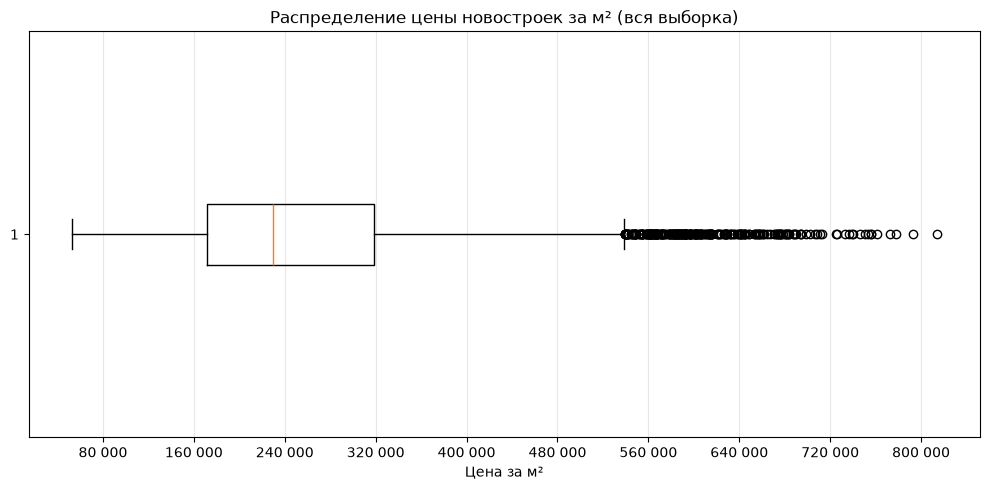

In [3]:
plot_price_boxplot(
    df_clean_new_builds['price_per_sqm'],
    'Распределение цены новостроек за м² (вся выборка)',
    delenia=12,
    width=10.0,
    height=5.0
)

Проверим правый "хвост" графика на ошибочные данные и выброски

In [4]:
df_clean_new_builds.nlargest(15, 'price_per_sqm')[['id', 'price_per_sqm', 'district', 'total_area', 'complex_class', 'to_center_km', 'price_rub', 'rooms']]

,id,price_per_sqm,district,total_area,complex_class,to_center_km,price_rub,rooms
3571,N003572,813800,Meshchansky,49.0,business,4.62,39876000,1
6624,N006625,793200,Yakimanka,99.7,comfort,2.88,79083000,4
6243,N006244,777600,Arbat,66.5,comfort,1.94,51713000,2
1696,N001697,772500,Arbat,75.3,comfort,1.94,58168000,3
3233,N003234,761300,Meshchansky,56.5,business,5.14,43014000,2
2415,N002416,755600,Yakimanka,43.3,comfort,1.38,32717000,1
3212,N003213,755600,Meshchansky,85.2,business,4.62,64374000,3
4398,N004399,753500,Yakimanka,39.3,comfort,1.38,29612000,1
5421,N005422,751000,Donskoy,92.6,premium,5.70,69541000,4
1760,N001761,745900,Presnensky,22.0,comfort,3.40,16409000,0


## Выделение премиум-сегмента

Разделим на 2 группы жилье: обычный сегмент и премиум-сегмент методом квартильного размаха

### Исправление методики: порог считается внутри года

**Здесь была методологическая ошибка, и ниже она разобрана, а не спрятана.**

Изначально порог премиум-сегмента считался один на всю таблицу: Q3 + 1.5 × IQR по всем объявлениям 2020-2026 годов сразу. Выглядело безобидно, но в разделе 8.5.2 глубокого анализа проверка показала, что это неверно.

Цены за период выросли, а порог зафиксирован на среднем уровне всего шестилетия. Из-за этого объявлению 2020 года нужно быть гораздо более выдающимся, чтобы получить метку премиума, чем объявлению 2026 года. Другими словами, `is_premium` частично кодировал не «дорогое жильё», а **«объявление размещено позже»**.

Правильный порог — свой для каждого года. Тогда премиум означает «дорогое относительно своего времени».

Ниже оба расчёта подряд: сначала старый, как было, потом новый, как стало, и сравнение.

**Шаг 1. Как было** — один порог на все годы (`add_premium_flag`). Функция намеренно оставлена в `src/segmentation.py`, чтобы ошибку можно было воспроизвести.

In [5]:
df_clean_new_builds = add_premium_flag(df_clean_new_builds, 'price_per_sqm')

Q1 = 171775
Q3 = 318625
IQR = 146850
Порог премиум-сегмента: 538900
is_premium
False    7709
True      291
Name: count, dtype: int64

Доля премиум-сегмента: 3.6%


**Шаг 2. Как стало** — порог внутри каждого года (`add_premium_flag_by_year`). Эта строка перезаписывает `is_premium`, и дальше по ноутбуку и во всём проекте используется уже она.

In [6]:
df_clean_new_builds = add_premium_flag_by_year(df_clean_new_builds, 'price_per_sqm')

      Объявлений  Порог года  Премиум, шт  Премиум, %
Год                                                  
2021        1480    470562.0           60         4.1
2022        1456    522988.0           46         3.2
2023        1547    567525.0           44         2.8
2024        1534    568000.0           54         3.5
2025        1527    570275.0           67         4.4
2026         456    514200.0           29         6.4

Всего премиум-сегмента: 300 (3.8%)


**Шаг 3. Что изменилось** — сравнение двух методов по годам.

In [7]:
premium_methods = compare_premium_methods(df_clean_new_builds, 'price_per_sqm')
print()
print(premium_methods.to_string())

Общий порог по всей выборке: 538 900
Премиум по общему порогу:  291 (3.6%)
Премиум по порогу года:    300 (3.8%)

Сменили метку: 117 объявлений из 8000 (1.5%)
  были премиумом, перестали: 54
  не были премиумом, стали:  63

      Объявлений  Порог года  Премиум по общему порогу, %  Премиум по порогу года, %  Сменили метку, шт
Год                                                                                                    
2021        1480    470562.0                          1.1                        4.1                 43
2022        1456    522988.0                          2.2                        3.2                 14
2023        1547    567525.0                          4.0                        2.8                 18
2024        1534    568000.0                          4.8                        3.5                 19
2025        1527    570275.0                          5.5                        4.4                 17
2026         456    514200.0                    

### Что дало исправление (новостройки)

Общий порог — 538 900 руб/м². Порог года прошёл с 470 562 в 2021 до 570 275 в 2025 и просел до 514 200 в 2026 (в 2026 всего 456 объявлений — год неполный, это видно по числу строк).

По старому методу доля премиума росла с 1.1% до 5.5% — та же болезнь, что и в двух других таблицах. Но по новому методу доля **не выравнивается полностью**: 2.8-6.4% по годам. И это честный результат, а не недоделка: IQR-порог не фиксирует долю, он реагирует на форму хвоста распределения, а у новостроек она год от года меняется сильнее, чем у вторички, где объявлений в шесть раз больше. Исправление убирает систематический дрейф, связанный с ростом цен, — оставшиеся колебания это уже свойство самих данных.

Сменили метку 117 объявлений из 8 000: 54 перестали быть премиумом, 63 стали.

Доля премиум-сегмента на порядок ниже, нежели в таблицах rentals и secondary_market, что говорит о спаде спроса на жилье данного типа в рассматриваемый период (2020-2026 гг.)

In [8]:
df_clean_new_builds[df_clean_new_builds['is_premium']].groupby('complex_class')['id'].count()

complex_class
business     72
comfort     120
economy      44
premium      64
Name: id, dtype: int64

Заметим, что в премиум-сегмент также попал эконом класс новостроек.
Разберемся, являются ли эти данные выбросами

Эконом класса, что очевидно, в премиум-выборке меньше всего - 44 из 300 (14,7%)

In [9]:
economy = df_clean_new_builds[df_clean_new_builds['complex_class'] == 'economy']

economy_by_district = (
    economy.groupby('district')['price_per_sqm']
    .median()
    .sort_values(ascending=False)
)

print(economy_by_district)

district
Tverskoy                      546350.0
Khamovniki                    505400.0
Zamoskvorechye                421300.0
Dorogomilovo                  381750.0
Meshchansky                   359950.0
Basmanny                      358750.0
Lomonosovsky                  305150.0
Krylatskoye                   283500.0
Fili-Davydkovo                278100.0
Khoroshyovsky                 270800.0
Begovoy                       264900.0
Sokol                         256200.0
Shchukino                     255000.0
Cheryomushki                  250250.0
Yasenevo                      247400.0
Kurkino                       233900.0
Sokolniki                     219600.0
Alekseevsky                   216400.0
Severnoye Tushino             206500.0
Nagatinsky Zaton              205800.0
Mitino                        203500.0
Severnoye Butovo              201000.0
Rostokino                     190850.0
Perovo                        190400.0
Koptevo                       189900.0
Solntsevo       

Покажем графически всю выборку премиум-сегмента в эконом классе

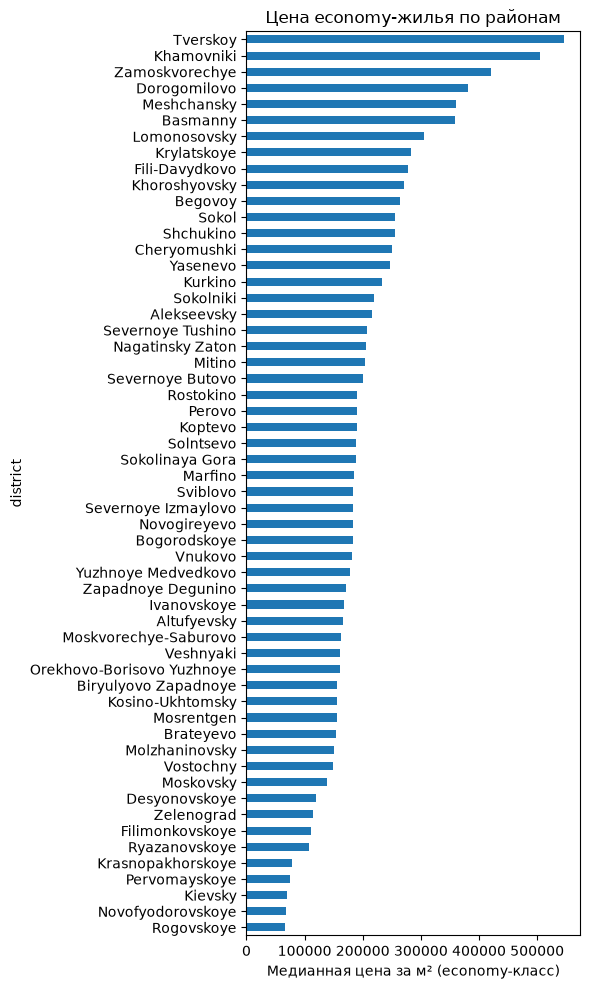

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 10))
economy_by_district.plot(kind='barh')
plt.xlabel('Медианная цена за м² (economy-класс)')
plt.title('Цена economy-жилья по районам')

plt.gca().invert_yaxis()  # сортировка от наибольшей стоимости к наименьшей
plt.tight_layout()
plt.show()

Проверим гипотезу: разница в цене между топ-10 самых дорогих и топ-10 самых дешёвых районов должна быть сопоставима с разницей, которую мы видели в среднем по рынку - если так, это не выброс, а закономерность локации

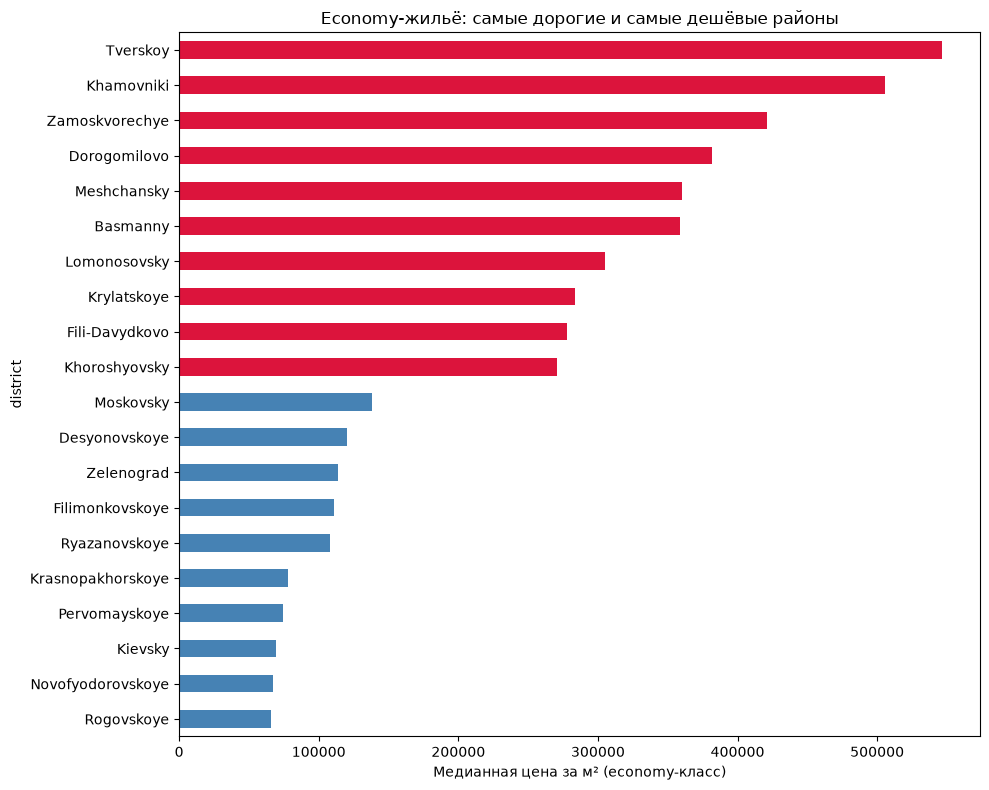

In [11]:
top_expensive = economy_by_district.head(10)
top_cheap = economy_by_district.tail(10)

combined = pd.concat([top_expensive, top_cheap])

plt.figure(figsize=(10, 8))
combined.plot(kind='barh', color=['crimson']*10 + ['steelblue']*10)
plt.xlabel('Медианная цена за м² (economy-класс)')
plt.title('Economy-жильё: самые дорогие и самые дешёвые районы')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# Относительная разница топ-10 дорогих от топ-10 дешевых
ratio = top_expensive.mean() / top_cheap.mean()
print(f"ratio = {ratio:.1f}")

ratio = 3.9


По графику видно - топ-10 дорогостоящих новостроек в среднем стоят в 3,9 раз дороже топ-10 менее стоящих новостроек данной выборки, что вполне адекватно для центральных районов Москвы
Таким образом, выборка эконом класса в элитных районах Москвы не является выбросами

Построим для наглядности график-боксплот, исключающий премиум-сегмент квартиры

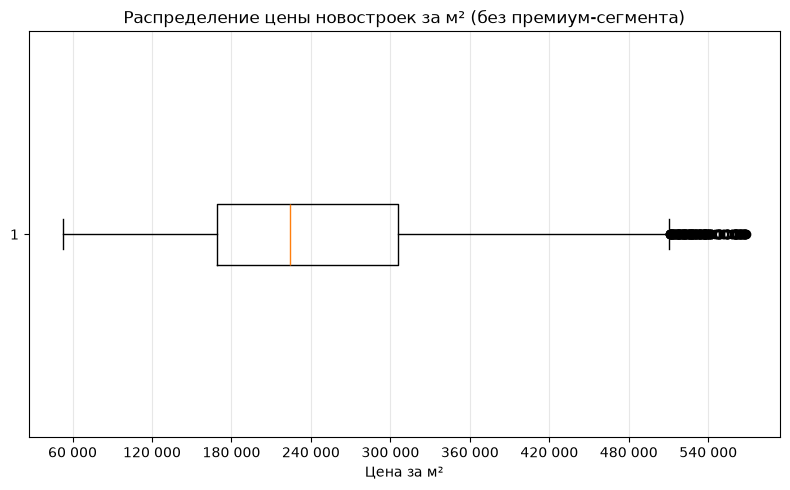

In [13]:
df_no_premium = df_clean_new_builds[~df_clean_new_builds['is_premium']]
plot_price_boxplot(
    df_no_premium['price_per_sqm'],
    'Распределение цены новостроек за м² (без премиум-сегмента)',
    delenia=10,
    width=8.0,
    height=5.0
)

Заметим, что на первый взгляд в таблицах также есть несоответствие в колонке metro_distance_min слишком большие значения, вплоть до 744 мин. Это присоединенная ранее или в течение периода "Новая Москва" в виде трех округов: "TAO", "NAO", "ZelAO"

## Выделение Новой Москвы

Разделим данные, аналогично с колонкой "is_premium"

In [14]:
df_clean_new_builds = add_new_moscow_flag(df_clean_new_builds)

is_new_moscow
False    6362
True     1638
Name: count, dtype: int64
Доля Новой Москвы: 20.5%


Также, оказалось, что доля новостроек Новой Москвы на 3.5% выше, нежели при съеме или покупке жилья. Можно сделать вывод, что застройщики делают высший приоритет именно для новых районов

In [15]:
df_clean_new_builds[df_clean_new_builds['is_new_moscow']]['is_premium'].value_counts()

is_premium
False    1638
Name: count, dtype: int64

Ни один объект Новой Москвы не попал в премиум-сегмент (0 из 1638). Это количественно доказывает, что Новая Москва - принципиально иной, более доступный сегмент рынка, а не часть единого "московского" распределения цен.

Важно: порог премиум-сегмента (IQR) считается внутри каждого года по всей выборке этого года, включая Новую Москву, а не отдельно по Старой Москве. Это не искажает результат: Новая Москва - компактный кластер низких цен, полностью лежащий ниже Q1 и Q3, и не образует собственных выбросов сверху. Она не может "перетянуть" границу премиум-сегмента, поэтому отдельный пересчёт порога по Старой Москве не требуется.

## Визуализация разницы Новой и Старой Москвы

In [16]:
compare_old_vs_new_moscow_median(df_clean_new_builds, 'price_per_sqm')

Старая Москва, медиана price_per_sqm: 258,150
Новая Москва, медиана price_per_sqm: 114,650
Разница: в 2.3 раз


## Бокс-плот

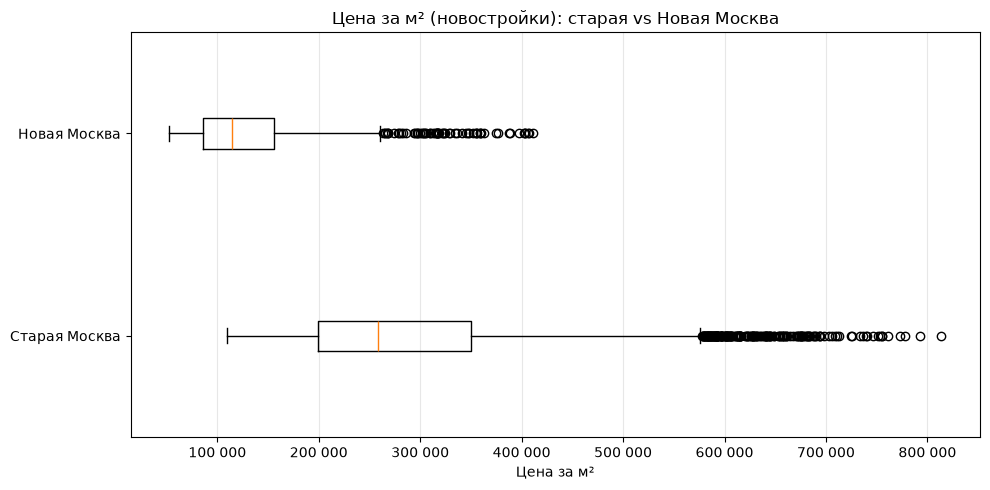

In [17]:
plot_old_vs_new_moscow_boxplot(df_clean_new_builds, 'price_per_sqm', 'новостройки')

Сделаем вывод, что рынок Старой Москвы более разнороден - есть как бюджетные варианты, так и элитное жилье. Новая Москва более однородна по ценам, однако на фоне вторички и съема не так сильно выражено, что означает большую конкуренцию и большие затраты на рынке новостроек

## Круговая диаграмма

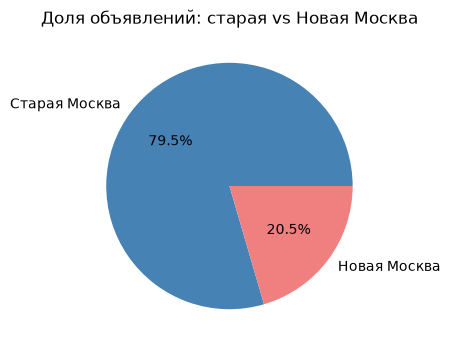

In [18]:
plot_new_moscow_share_pie(df_clean_new_builds)

Сохраним новые данные в измененную таблицу processed

In [19]:
df_clean_new_builds.to_csv('data/processed/clean_new_builds.csv', index=False)